In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

# Load datasets
fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")

nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

aum = pd.read_csv(
    "../data/processed/aum_clean.csv"
)

sip = pd.read_csv(
    "../data/processed/sip_clean.csv"
)

category = pd.read_csv(
    "../data/processed/category_clean.csv"
)

folios = pd.read_csv(
    "../data/processed/folios_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/transactions_clean.csv"
)

holdings = pd.read_csv(
    "../data/processed/holdings_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/benchmark_clean.csv"
)

In [10]:
import plotly.io as pio

pio.kaleido.scope.mathjax = None

C:\Users\User\AppData\Local\Temp\ipykernel_12636\1975508219.py:3: DeprecationWarning: 
Use of plotly.io.kaleido.scope.mathjax is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.mathjax instead.

  pio.kaleido.scope.mathjax = None


In [11]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

### NAV Trend Insight

Most mutual fund schemes experienced consistent NAV growth between 2022 and 2025, with accelerated growth observed during the 2023 bull market.

In [12]:
fig.write_image(
    "../reports/nav_trend.png"
)

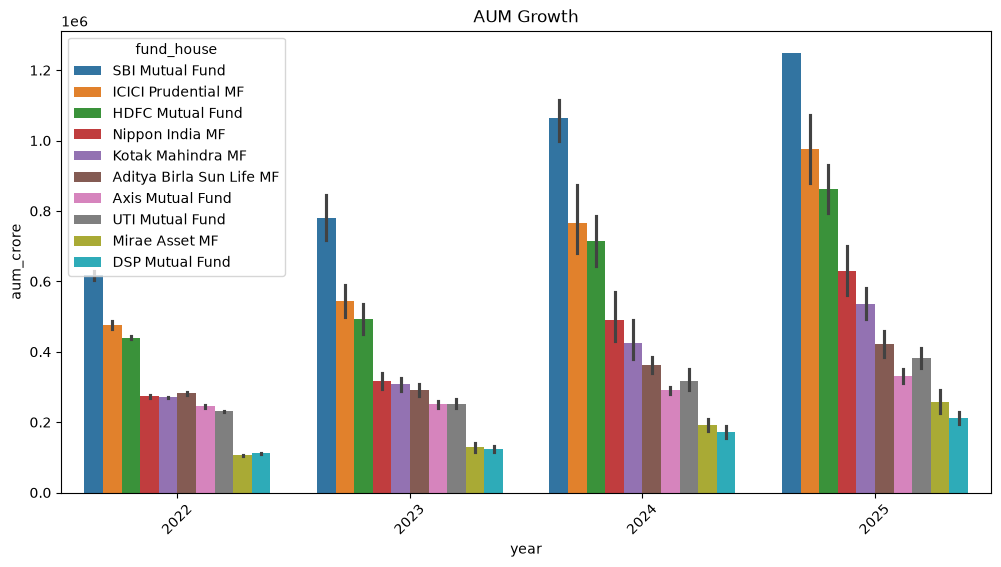

In [13]:
aum["year"] = pd.to_datetime(
    aum["date"]
).dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth")
plt.xticks(rotation=45)

plt.savefig(
    "../reports/aum_growth.png"
)

plt.show()

### AUM Growth Insight 

SBI Mutual Fund maintained market leadership with AUM exceeding ₹12.5 lakh crore, significantly outperforming other fund houses.

In [15]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

sip["month_str"] = (
    sip["month"]
    .dt.strftime("%b-%Y")
)

max_index = sip["sip_inflow_crore"].idxmax()

max_month = sip.loc[
    max_index,
    "month_str"
]

max_value = sip.loc[
    max_index,
    "sip_inflow_crore"
]

fig = px.line(
    sip,
    x="month_str",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x=max_month,
    y=max_value,
    text="₹31,002 Cr High",
    showarrow=True
)

fig.show()

fig.write_image(
    "../reports/sip_trend.png"
)

### SIP Inflows Insight 

Monthly SIP inflows showed a strong upward trend, reaching an all-time high of ₹31,002 crore in December 2025.

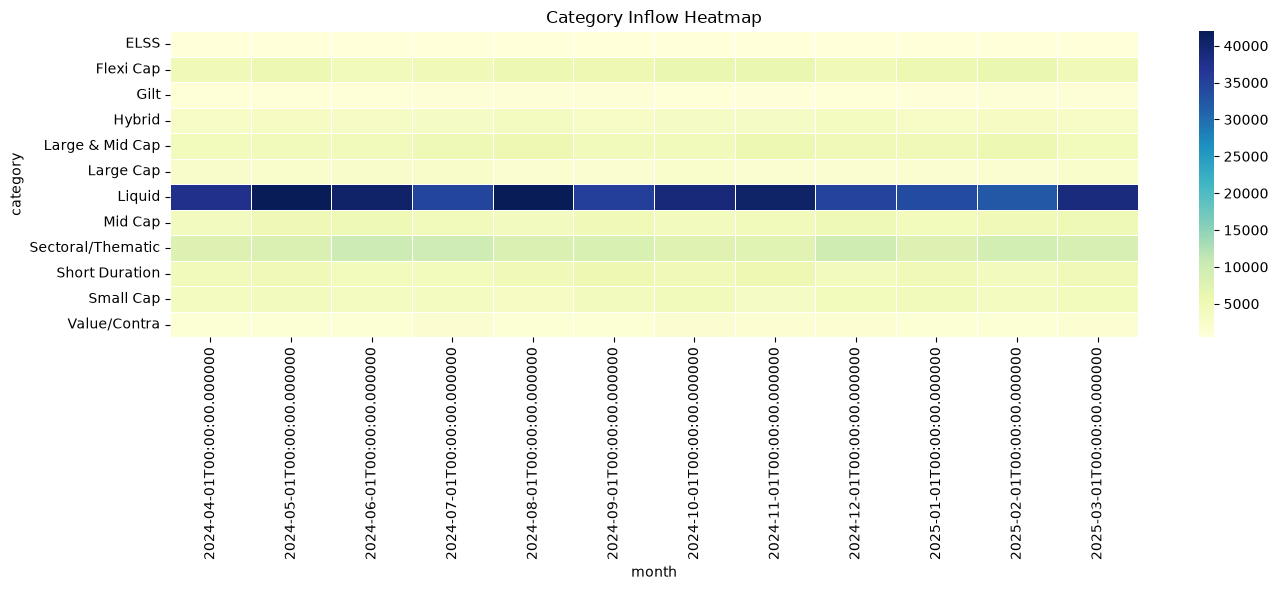

In [16]:
category["month"] = pd.to_datetime(
    category["month"]
)

pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Category Inflow Heatmap"
)

plt.tight_layout()

plt.savefig(
    "../reports/category_heatmap.png"
)

plt.show()

### Category Inflows Insight 

Equity-oriented categories consistently attracted higher inflows compared to debt and hybrid categories.

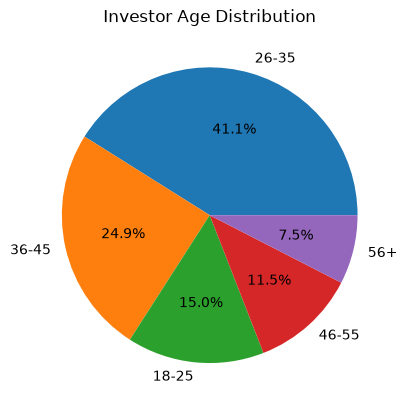

In [17]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Distribution"
)

plt.ylabel("")

plt.savefig(
    "../reports/age_distribution.png"
)

plt.show()

### Investor Age Distribution Insight 

The majority of investors belong to the 25–40 age group, indicating strong participation from young investors.

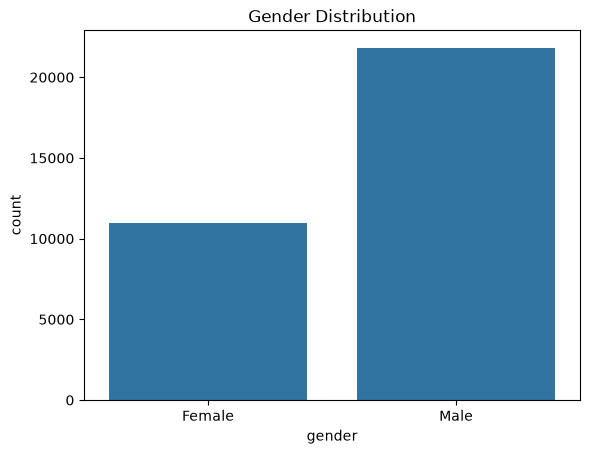

In [18]:
sns.countplot(
    data=transactions,
    x="gender"
)

plt.title(
    "Gender Distribution"
)

plt.savefig(
    "../reports/gender_split.png"
)

plt.show()

### Investor Gender Distribution Insight 

Male investors contribute a larger share of mutual fund transactions compared to female investors.

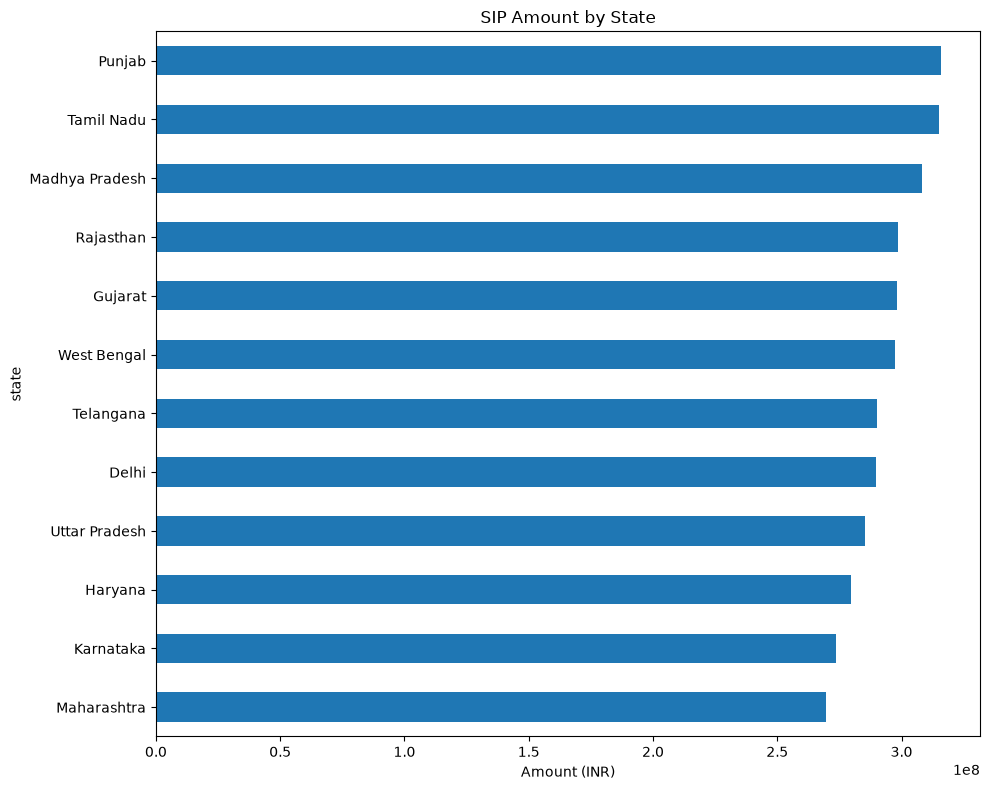

In [19]:
state = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

state.plot(
    kind="barh"
)

plt.title(
    "SIP Amount by State"
)

plt.xlabel(
    "Amount (INR)"
)

plt.tight_layout()

plt.savefig(
    "../reports/state_distribution.png"
)

plt.show()

### Geographic Distribution Insight 

A small number of states contribute a disproportionately large share of SIP investments.

<Figure size 1000x500 with 0 Axes>

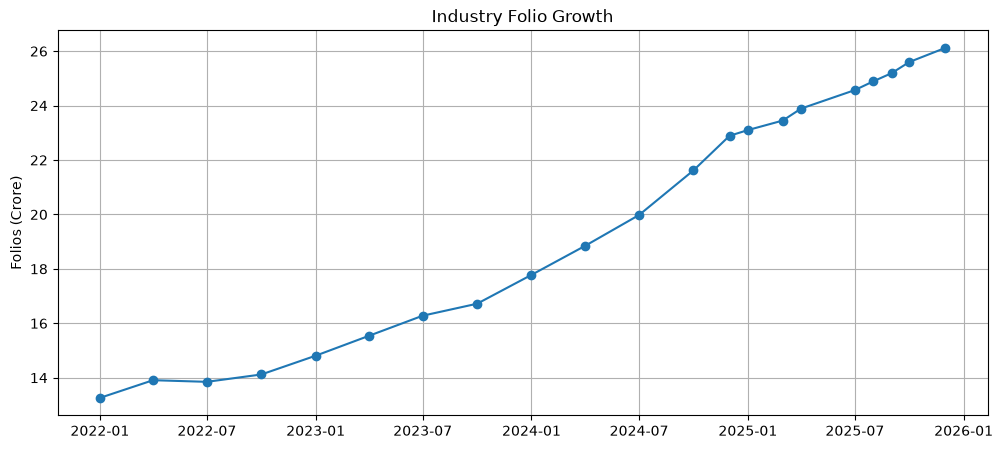

In [20]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(10,5))

folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(12,5))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.title(
    "Industry Folio Growth"
)

plt.ylabel(
    "Folios (Crore)"
)

plt.grid(True)

plt.savefig(
    "../reports/folio_growth.png"
)

plt.show()

### Folio Insight 

Industry folio count nearly doubled between 2022 and 2025, reflecting increasing retail participation.

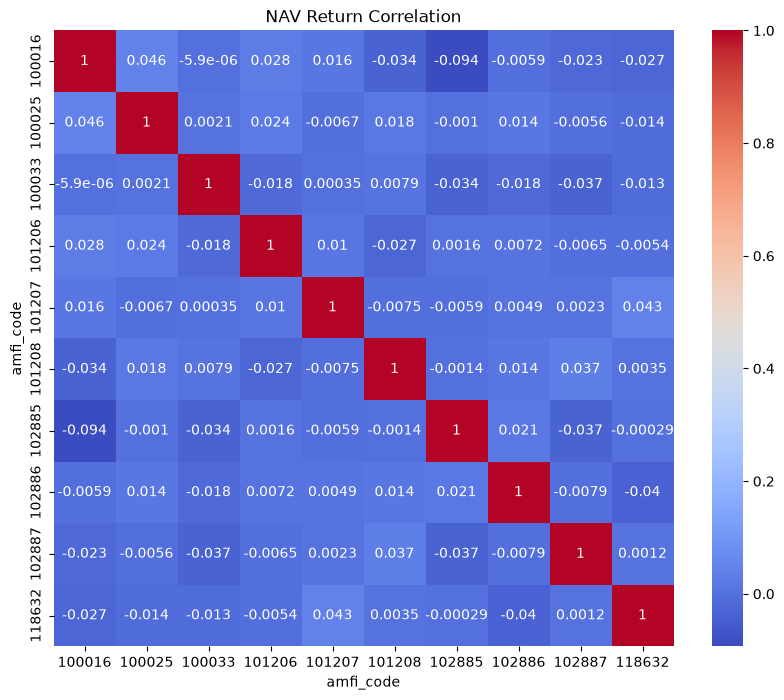

In [21]:
top10 = nav[
    nav["amfi_code"]
    .isin(
        nav["amfi_code"]
        .unique()[:10]
    )
]

pivot = top10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation"
)

plt.savefig(
    "../reports/correlation.png"
)

plt.show()

### Correlation Insight 

Several large-cap schemes exhibit high return correlation, suggesting similar portfolio compositions.

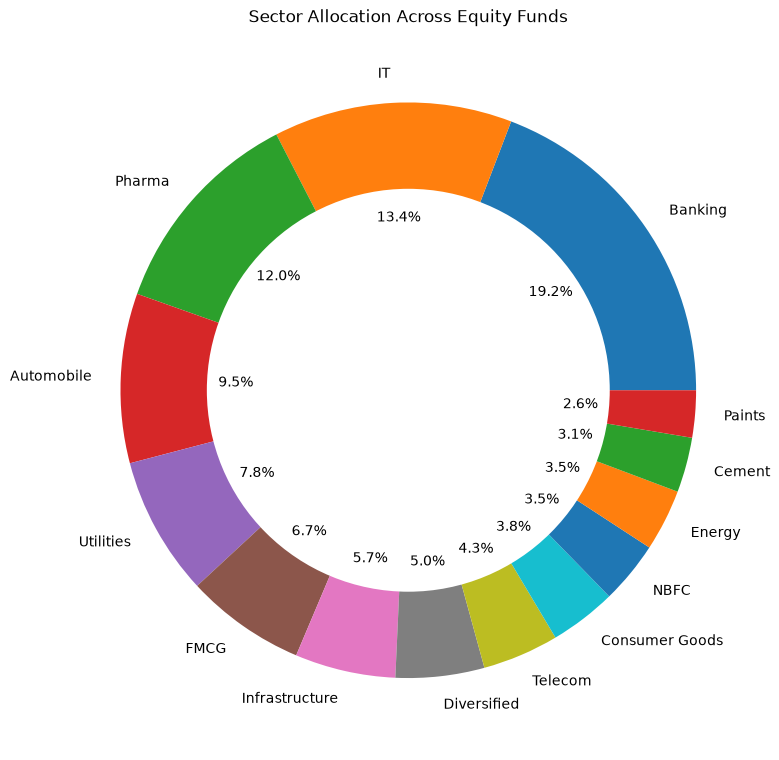

In [22]:
sector = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(
    "Sector Allocation Across Equity Funds"
)

plt.tight_layout()

plt.savefig(
    "../reports/sector_donut.png"
)

plt.show()

### Sector Allocation Across Equity Funds

The portfolio holdings analysis indicates that sector allocation is concentrated in Financial Services, Information Technology, and Healthcare constitute a significant portion of total portfolio weight, reflecting fund managers' preference for established and growth-oriented industries.

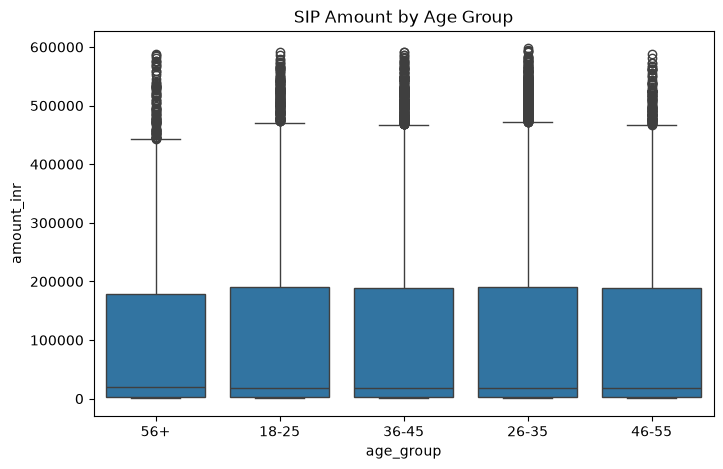

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount by Age Group"
)

plt.savefig(
    "../reports/sip_age_boxplot.png"
)

plt.show()

### SIP Amount Distribution by Age Group

 Middle-aged investors generally contribute higher SIP amounts and exhibit greater investment variability, while younger investors tend to invest smaller and more consistent amounts. Older age groups demonstrate relatively stable investment patterns with lower dispersion.

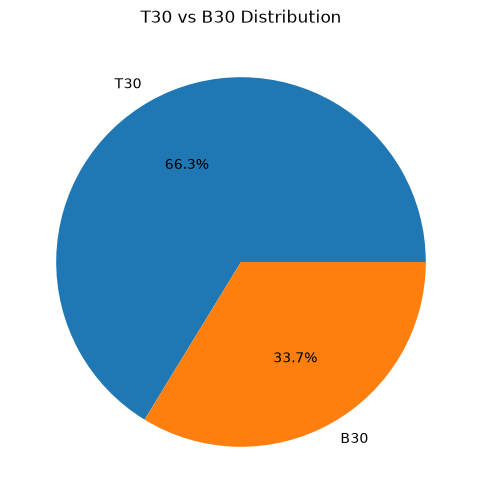

In [24]:
tier = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Distribution"
)

plt.savefig(
    "../reports/t30_b30.png"
)

plt.show()

### T30 Vs B30 Insight 

T30 cities continue to dominate investments, although B30 participation is steadily increasing.